#### Imports and Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install shap -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyreadstat
import shap
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
BLUE   = "#2C6E9B"
RED    = "#C0392B"
GREEN  = "#27AE60"
ORANGE = "#E67E22"
PURPLE = "#8E44AD"
GRAY   = "#7F8C8D"
BG     = "#F8F9FA"
 
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

#### Data Construction and EDA

Six county-level datasets merged on 5-digit FIPS code (`state * 1000 + county`).

| Dataset | File | Key variables pulled |
|---|---|---|
| Opportunity Atlas (2018) | `county_outcomes_dta.dta` | `kfr_pooled_pooled_p25`, race × sex mobility at p25:  **primary outcome** |
| Geography of Mobility (2014) | `onlinedata3.dta` | `gini`, `inc_share_1perc`, `s_rank_8082` |
| Changing Opportunity (2022) | `cty_covariates.dta` | `mean_commutetime2000`, `gsmn_math_g3_2013`, `singleparent_share2010`, `poor_share2010` |
| Race & Economic Opportunity (2020) | `Table_8_county_covariates.dta` | `gini2010`, `singlepar_pooled2010`, `poor_share_black2010` |
| Social Capital I (2022) | `social_capital_county.csv` | `ec_county` (economic connectedness) |
| NCHS Urban-Rural (2013) | `NCHSurb-rural-codes.csv` | `CODE2013` (6-level urban-rural class) |

In [5]:
import pyreadstat
import pandas as pd

df14, _ = pyreadstat.read_dta("onlinedata3 (2).dta")
df14 = df14.rename(columns={"county_id": "fips"})
df14["fips"] = df14["fips"].astype(int)

cov, _ = pyreadstat.read_dta("cty_covariates.dta")
cov["fips"] = cov["state"].astype(int) * 1000 + cov["county"].astype(int)

t8, _ = pyreadstat.read_dta("Table_8_county_covariates.dta")
t8["fips"] = t8["state"].astype(int) * 1000 + t8["county"].astype(int)

key_cols = ["state", "county", "cz", "czname",
            "kfr_black_male_p25",   "kfr_black_female_p25",
            "kfr_white_male_p25",   "kfr_white_female_p25",
            "kfr_hisp_male_p25",    "kfr_hisp_female_p25",
            "kfr_pooled_male_p25",  "kfr_pooled_female_p25",
            "kfr_pooled_pooled_p25"]
df_out, _ = pyreadstat.read_dta("county_outcomes_dta.dta", usecols=key_cols)
df_out["fips"] = df_out["state"].astype(int) * 1000 + df_out["county"].astype(int)

sc = pd.read_csv("social_capital_county.csv")
sc = sc.rename(columns={"county": "fips"})
sc["fips"] = sc["fips"].astype(int)
sc = sc[["fips", "ec_county", "clustering_county",
         "support_ratio_county", "volunteering_rate_county",
         "civic_organizations_county"]]

nchs = pd.read_csv("NCHSurb-rural-codes.csv", encoding="latin1")
nchs["fips"] = nchs["STFIPS"] * 1000 + nchs["CTYFIPS"]
nchs_ur = nchs[["fips", "CODE2013"]].rename(columns={"CODE2013": "urban_rural_code"})
nchs_ur["urban_rural_label"] = nchs_ur["urban_rural_code"].map({
    1: "Large Central Metro", 2: "Large Fringe Metro",
    3: "Medium Metro",        4: "Small Metro",
    5: "Micropolitan",        6: "Noncore Rural"
})

df = (df_out
      .merge(df14[["fips", "s_rank_8082", "e_rank_b", "gini", "inc_share_1perc",
                   "p75_less_p25_within", "frac_kteenbirthfem"]], on="fips", how="left")
      .merge(cov[["fips", "mean_commutetime2000", "gsmn_math_g3_2013",
                  "singleparent_share2010", "poor_share2010", "med_hhinc2016",
                  "traveltime15_2010", "ann_avg_job_growth_2004_2013",
                  "popdensity2010"]], on="fips", how="left")
      .merge(t8[["fips", "gini2010", "singlepar_pooled2010",
                 "share_black2010", "poor_share_black2010"]], on="fips", how="left")
      .merge(sc, on="fips", how="left")
      .merge(nchs_ur, on="fips", how="left")
)

df.head(10)

,state,county,cz,czname,kfr_black_female_p25,kfr_hisp_female_p25,kfr_pooled_female_p25,kfr_white_female_p25,kfr_black_male_p25,kfr_hisp_male_p25,...,singlepar_pooled2010,share_black2010,poor_share_black2010,ec_county,clustering_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,urban_rural_code,urban_rural_label
0,1.0,1.0,11101.0,Montgomery,0.316532,0.444835,0.373302,0.416631,0.297059,0.412351,...,0.276716,0.176706,0.275211,0.72077,0.10347,0.98275,0.04355,0.01518,3.0,Medium Metro
1,1.0,3.0,11001.0,Mobile,0.305977,0.461809,0.399215,0.435208,0.298181,0.429707,...,0.288834,0.093847,0.328424,0.74313,0.09624,0.98684,0.06117,0.01526,4.0,Small Metro
2,1.0,5.0,10301.0,Eufaula,0.311012,NaN,0.356089,0.439702,0.306210,NaN,...,0.473958,0.468915,0.394491,0.41366,0.14911,0.99911,0.02093,0.01474,6.0,Noncore Rural
3,1.0,7.0,10801.0,Tuscaloosa,0.307754,NaN,0.355845,0.386489,0.311230,NaN,...,0.317542,0.220249,0.252901,0.63152,0.14252,0.99716,0.05294,0.01439,2.0,Large Fringe Metro
4,1.0,9.0,10700.0,Birmingham,0.325251,0.435408,0.401055,0.415529,0.267119,0.473139,...,0.224192,0.013276,0.321229,0.72562,0.11243,0.99069,0.05704,0.01724,2.0,Large Fringe Metro
5,1.0,11.0,9800.0,Auburn,0.329223,NaN,0.349057,0.501848,0.324206,NaN,...,0.600787,0.702401,0.323285,0.35515,0.18581,1.00000,0.01713,0.00975,6.0,Noncore Rural
6,1.0,13.0,11101.0,Montgomery,0.311344,NaN,0.357346,0.417858,0.309114,NaN,...,0.448842,0.434191,0.373386,0.46026,0.16094,1.00000,0.03807,0.01286,6.0,Noncore Rural
7,1.0,15.0,9600.0,LaGrange,0.330084,0.377225,0.373840,0.408250,0.299533,0.419859,...,0.374189,0.205630,0.383397,0.60189,0.11236,0.99701,0.05313,0.01739,4.0,Small Metro
8,1.0,17.0,9600.0,LaGrange,0.321685,NaN,0.348502,0.384330,0.313022,NaN,...,0.455874,0.387462,0.349695,0.49761,0.13574,0.99759,0.02566,0.01098,5.0,Micropolitan
9,1.0,19.0,6600.0,Rome,0.305133,NaN,0.362285,0.387946,0.302280,NaN,...,0.291386,0.046481,0.275424,0.60461,0.12273,0.99697,0.04666,0.01796,6.0,Noncore Rural


In [6]:
df.shape

(3219, 39)

#### Feature Engineering

Constructed variables used in all models:-

| Variable | Construction | Interpretation |
|---|---|---|
| `mobility` | = `kfr_pooled_pooled_p25` | Primary outcome: mean income rank of children with parents at p25 |
| `racial_gap_wb` | = `kfr_white_male_p25 − kfr_black_male_p25` | White−Black male opportunity gap |
| `gender_gap_black` | = `kfr_black_female_p25 − kfr_black_male_p25` | Gender gap within Black community |
| `seg_score` | = `poor_share_black2010`, fallback to `poor_share2010` | Racial-economic concentration (segregation proxy) |
| `inequality` | = `gini2010`, fallback to `gini` | Income inequality |
| `single_parent` | = `singlepar_pooled2010`, fallback to `singleparent_share2010` | Share of single-parent households |
| `school_quality` | = `gsmn_math_g3_2013` | Average 3rd-grade math score (Stanford Ed. Opp. Project) |
| `commute` | = `mean_commutetime2000` | Average commute time, 2000 |
| `social_capital` | = `ec_county` | Economic connectedness |
| `seg_hi` | = `poor_share_black2010 > median` | Binary: high-segregation county |
| `pov_hi` | = `poor_share2010 > median` | Binary: high-poverty county |
| `regime_label` | 2×2 cross of `seg_hi` × `pov_hi` | Segregation-poverty regime for subgroup analysis |

In [7]:
df["mobility"]       = df["kfr_pooled_pooled_p25"]
df["racial_gap_wb"]  = df["kfr_white_male_p25"] - df["kfr_black_male_p25"]
df["gender_gap_black"] = df["kfr_black_female_p25"] - df["kfr_black_male_p25"]

df["seg_score"]      = df["poor_share_black2010"].fillna(df["poor_share2010"])
df["inequality"]     = df["gini2010"].fillna(df["gini"])
df["single_parent"]  = df["singlepar_pooled2010"].fillna(df["singleparent_share2010"])
df["school_quality"] = df["gsmn_math_g3_2013"]
df["commute"]        = df["mean_commutetime2000"]
df["social_capital"] = df["ec_county"]

df["seg_hi"]  = df["poor_share_black2010"] > df["poor_share_black2010"].median()
df["pov_hi"]  = df["poor_share2010"] > df["poor_share2010"].median()
df["regime_label"] = (df["seg_hi"].astype(str) + "_seg_" +
                      df["pov_hi"].astype(str) + "_pov").map({
    "True_seg_True_pov":   "High Seg / High Pov",
    "True_seg_False_pov":  "High Seg / Low Pov",
    "False_seg_True_pov":  "Low Seg / High Pov",
    "False_seg_False_pov": "Low Seg / Low Pov",
})

cols_to_show = ["mobility", "racial_gap_wb", "gender_gap_black",
                "seg_score", "inequality", "single_parent",
                "school_quality", "commute", "social_capital", "regime_label"]

df["ur_code"] = df["urban_rural_code"]

df[cols_to_show].head(10)

,mobility,racial_gap_wb,gender_gap_black,seg_score,inequality,single_parent,school_quality,commute,social_capital,regime_label
0,0.361666,0.100258,0.019473,0.275211,0.405,0.276716,2.759864,28.490602,0.72077,Low Seg / Low Pov
1,0.388847,0.120363,0.007796,0.328424,0.439,0.288834,2.792510,26.501080,0.74313,High Seg / Low Pov
2,0.349386,0.123980,0.004802,0.394491,0.464,0.473958,1.600009,24.047514,0.41366,High Seg / High Pov
3,0.363391,0.098941,-0.003476,0.252901,0.411,0.317542,1.531674,32.875317,0.63152,Low Seg / Low Pov
4,0.391879,0.125811,0.058132,0.321229,0.422,0.224192,2.815403,36.189240,0.72562,High Seg / Low Pov
5,0.345659,0.161720,0.005018,0.323285,0.533,0.600787,1.039439,26.251190,0.35515,High Seg / High Pov
6,0.357249,0.123074,0.002229,0.373386,0.463,0.448842,1.526850,26.863214,0.46026,High Seg / High Pov
7,0.361847,0.092772,0.030550,0.383397,0.453,0.374189,3.283976,24.250038,0.60189,High Seg / High Pov
8,0.340575,0.063582,0.008664,0.349695,0.425,0.455874,2.144036,23.371609,0.49761,High Seg / High Pov
9,0.365422,0.082614,0.002854,0.275424,0.439,0.291386,1.712031,30.194675,0.60461,High Seg / High Pov


In [8]:
PREDICTORS = ["seg_score", "school_quality", "single_parent",
              "inequality", "commute", "social_capital",
              "poor_share2010", "med_hhinc2016", "popdensity2010"]

analytic = df[["fips", "czname", "urban_rural_label", "ur_code",
               "regime_label", "mobility", "racial_gap_wb", "gender_gap_black",
               "kfr_black_male_p25", "kfr_white_male_p25",
               "kfr_black_female_p25", "kfr_white_female_p25"] + PREDICTORS].dropna()

print(f"Analytic sample: {len(analytic)} counties (dropped {len(df)-len(analytic)} for missing)")

analytic[["mobility"] + PREDICTORS].head(10)

Analytic sample: 1578 counties (dropped 1641 for missing)


,mobility,seg_score,school_quality,single_parent,inequality,commute,social_capital,poor_share2010,med_hhinc2016,popdensity2010
0,0.361666,0.275211,2.759864,0.276716,0.405,28.490602,0.72077,0.105918,54052.804457,91.802681
1,0.388847,0.328424,2.792510,0.288834,0.439,26.501080,0.74313,0.122942,52003.093474,114.647507
2,0.349386,0.394491,1.600009,0.473958,0.464,24.047514,0.41366,0.250631,33114.854828,31.029207
3,0.363391,0.252901,1.531674,0.317542,0.411,32.875317,0.63152,0.126850,39846.446520,36.806339
4,0.391879,0.321229,2.815403,0.224192,0.422,36.189240,0.72562,0.133138,46361.122396,88.902191
5,0.345659,0.323285,1.039439,0.600787,0.533,26.251190,0.35515,0.280449,31304.783397,17.523945
6,0.357249,0.373386,1.526850,0.448842,0.463,26.863214,0.46026,0.255558,34026.987254,26.964750
7,0.361847,0.383397,3.283976,0.374189,0.453,24.250038,0.60189,0.200562,42474.473064,200.312195
8,0.340575,0.349695,2.144036,0.455874,0.425,23.371609,0.49761,0.203779,35054.860061,57.356522
9,0.365422,0.275424,1.712031,0.291386,0.439,30.194675,0.60461,0.172289,38793.719997,46.936970


#### Initial EDA

_Figure 1: Distribution of Mobility and Urban-Rural Patterns_

Three panels:
1. Distribution of upward mobility across all 1,578 counties
2. Mobility by NCHS urban-rural class (large central metro → noncore rural)
3. Overall mobility vs. White−Black male gap, colored by urban-rural class

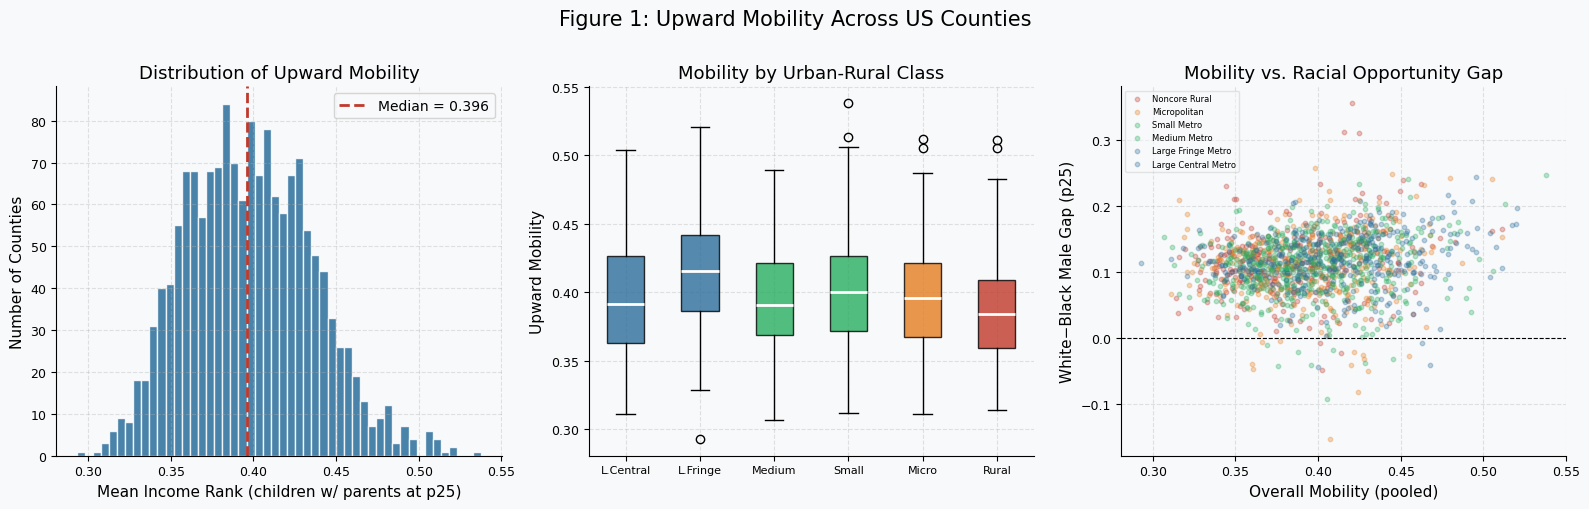

In [9]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 1: Upward Mobility Across US Counties", fontsize=15, y=1.01)

# Panel 1: histogram
ax = axes[0]
ax.hist(analytic["mobility"], bins=50, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(analytic["mobility"].median(), color=RED, lw=2, ls="--",
           label=f'Median = {analytic["mobility"].median():.3f}')
ax.set_xlabel("Mean Income Rank (children w/ parents at p25)")
ax.set_ylabel("Number of Counties")
ax.set_title("Distribution of Upward Mobility")
ax.legend()

# Panel 2: boxplot by urban-rural class
ax = axes[1]
ur_order = ["Large Central Metro", "Large Fringe Metro", "Medium Metro",
              "Small Metro", "Micropolitan", "Noncore Rural"]
colors_ur = [BLUE, BLUE, GREEN, GREEN, ORANGE, RED]
data_ur = [analytic.loc[analytic["urban_rural_label"] == u, "mobility"].dropna()
              for u in ur_order]
bp = ax.boxplot(data_ur, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2))
for patch, c in zip(bp["boxes"], colors_ur):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_xticks(range(1, 7))
ax.set_xticklabels(["L.Central", "L.Fringe", "Medium", "Small", "Micro", "Rural"],
                   fontsize=8)
ax.set_ylabel("Upward Mobility")
ax.set_title("Mobility by Urban-Rural Class")

# Panel 3: mobility vs racial gap
ax = axes[2]
for ur, color in zip(ur_order[::-1], [RED, ORANGE, GREEN, GREEN, BLUE, BLUE]):
    sub = analytic[analytic["urban_rural_label"] == ur]
    ax.scatter(sub["mobility"], sub["racial_gap_wb"],
               alpha=0.3, s=10, color=color, label=ur)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Overall Mobility (pooled)")
ax.set_ylabel("White−Black Male Gap (p25)")
ax.set_title("Mobility vs. Racial Opportunity Gap")
ax.legend(fontsize=6, loc="upper left", framealpha=0.5)

plt.tight_layout()

_Figure 2: Correlations and Segregation × Poverty Regimes_

Three panels:
1. Correlation heatmap of outcome and all 9 predictors
2. Mobility distribution across the 4 segregation × poverty regimes
3. Race × sex mobility (Black/White men/women) within each regime

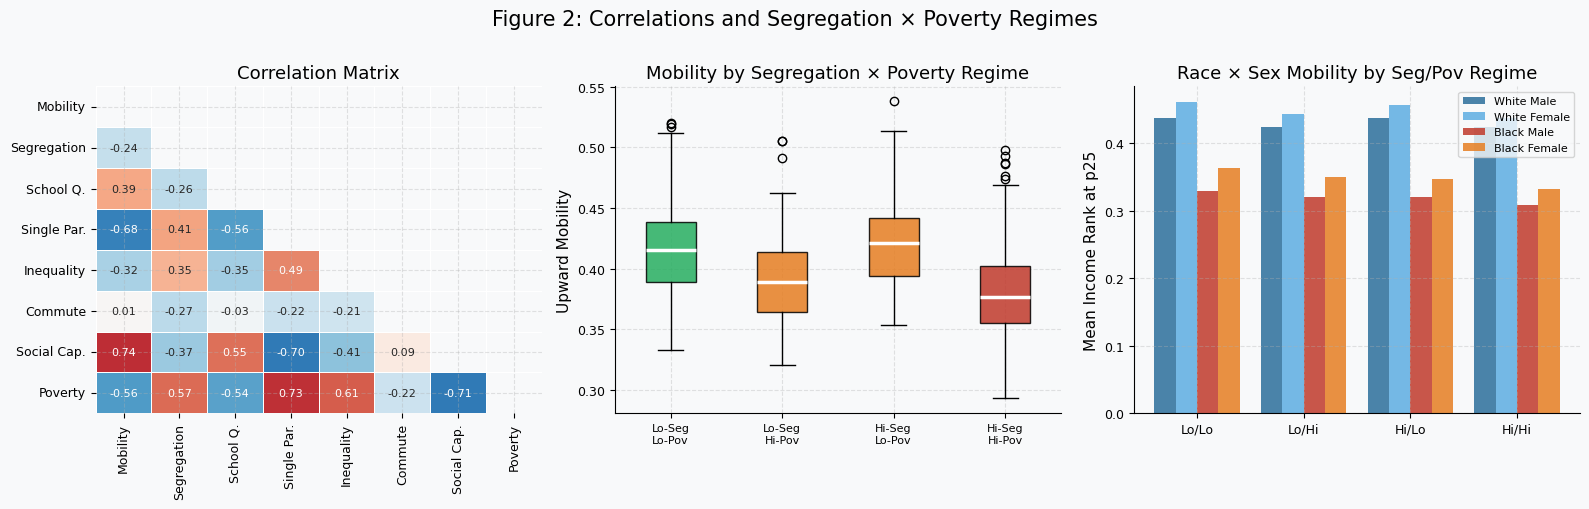

In [10]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 2: Correlations and Segregation × Poverty Regimes", fontsize=15, y=1.01)

# Panel 1: correlation heatmap
ax = axes[0]
corr_cols = ["mobility", "seg_score", "school_quality", "single_parent",
               "inequality", "commute", "social_capital", "poor_share2010"]
corr_labels = ["Mobility", "Segregation", "School Q.", "Single Par.",
               "Inequality", "Commute", "Social Cap.", "Poverty"]
corr_mat = analytic[corr_cols].corr()
corr_mat.index = corr_labels
corr_mat.columns = corr_labels
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 8}, linewidths=0.4, cbar=False)
ax.set_title("Correlation Matrix")

# Panel 2: mobility by regime
ax = axes[1]
regime_order = ["Low Seg / Low Pov", "Low Seg / High Pov",
                 "High Seg / Low Pov", "High Seg / High Pov"]
regime_colors = [GREEN, ORANGE, ORANGE, RED]
data_reg = [analytic.loc[analytic["regime_label"] == r, "mobility"].dropna()
            for r in regime_order]
bp2 = ax.boxplot(data_reg, patch_artist=True,
                 medianprops=dict(color="white", lw=2.5))
for patch, c in zip(bp2["boxes"], regime_colors):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(["Lo-Seg\nLo-Pov", "Lo-Seg\nHi-Pov",
                    "Hi-Seg\nLo-Pov", "Hi-Seg\nHi-Pov"], fontsize=8)
ax.set_ylabel("Upward Mobility")
ax.set_title("Mobility by Segregation × Poverty Regime")

# Panel 3: race x sex mobility by regime
ax = axes[2]
race_sex = {
    "White Male":   ("kfr_white_male_p25",  BLUE),
    "White Female": ("kfr_white_female_p25", "#5DADE2"),
    "Black Male":   ("kfr_black_male_p25",   RED),
    "Black Female": ("kfr_black_female_p25", ORANGE),
}
x = np.arange(4)
width = 0.2
for i, (label, (col, color)) in enumerate(race_sex.items()):
    means = [analytic.loc[analytic["regime_label"] == r, col].mean()
             for r in regime_order]
    ax.bar(x + i * width, means, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(["Lo/Lo", "Lo/Hi", "Hi/Lo", "Hi/Hi"], fontsize=9)
ax.set_ylabel("Mean Income Rank at p25")
ax.set_title("Race × Sex Mobility by Seg/Pov Regime")
ax.legend(fontsize=8)

plt.tight_layout()

### OLS Model


(1) Baseline OLS regresses upward mobility on 9 standardized predictors using HC3 heteroskedasticity-robust standard errors. A second model adds four interaction terms motivated by theory: segregation × school quality, segregation × single-parent share, inequality × single-parent share, and segregation × social capital.Coefficients are standardized (predictors scaled to mean 0, SD 1) so magnitudes are directly comparable across variables.

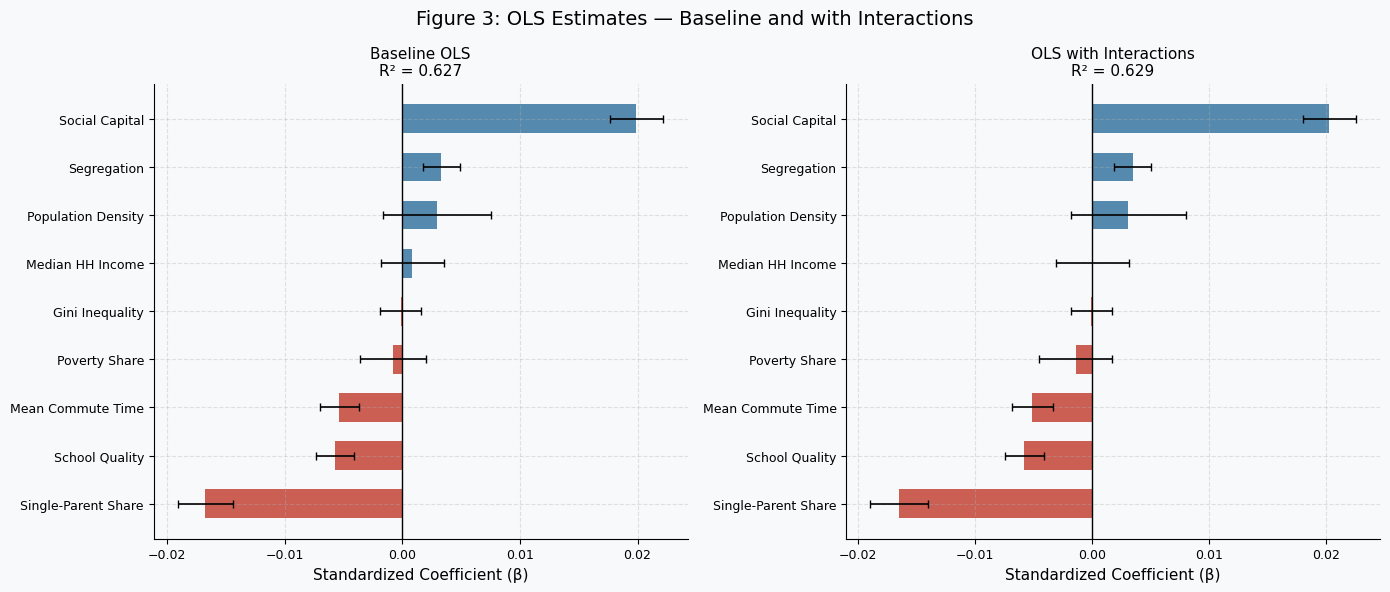

In [11]:
%matplotlib inline
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Standardize predictors
X_raw = analytic[PREDICTORS].copy()
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_raw), columns=PREDICTORS, index=X_raw.index)
y = analytic["mobility"]

# Baseline OLS
X_ols = sm.add_constant(X_std)
ols_base = sm.OLS(y, X_ols).fit(cov_type="HC3")

# OLS with interactions — copy analytic and attach standardized columns
analytic_std = analytic.copy()
for col in PREDICTORS:
    analytic_std[col] = X_std[col].values

formula_interact = (
    "mobility ~ seg_score + school_quality + single_parent + "
    "inequality + commute + social_capital + poor_share2010 + "
    "med_hhinc2016 + popdensity2010 + "
    "seg_score:school_quality + seg_score:single_parent + "
    "inequality:single_parent + seg_score:social_capital"
)
ols_interact = smf.ols(formula_interact, data=analytic_std).fit(cov_type="HC3")

pred_labels = {
    "seg_score":      "Segregation",
    "school_quality": "School Quality",
    "single_parent":  "Single-Parent Share",
    "inequality":     "Gini Inequality",
    "commute":        "Mean Commute Time",
    "social_capital": "Social Capital",
    "poor_share2010": "Poverty Share",
    "med_hhinc2016":  "Median HH Income",
    "popdensity2010": "Population Density",
}

def coef_plot(ax, model, title):
    params = model.params.drop("const", errors="ignore")
    cis = model.conf_int().drop("const", errors="ignore")
    params = params[params.index.isin(PREDICTORS)].sort_values()
    cis = cis.loc[params.index]
    y_pos = np.arange(len(params))
    colors_ = [RED if v < 0 else BLUE for v in params.values]
    ax.barh(y_pos, params.values, color=colors_, alpha=0.8, height=0.6)
    ax.errorbar(params.values, y_pos,
                xerr=[params - cis[0], cis[1] - params],
                fmt="none", color="black", lw=1.2, capsize=3)
    ax.axvline(0, color="black", lw=1.0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([pred_labels.get(v, v) for v in params.index], fontsize=9)
    ax.set_xlabel("Standardized Coefficient (β)")
    ax.set_title(f"{title}\nR² = {model.rsquared:.3f}", fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 3: OLS Estimates — Baseline and with Interactions", fontsize=14)
coef_plot(axes[0], ols_base,     "Baseline OLS")
coef_plot(axes[1], ols_interact, "OLS with Interactions")
plt.tight_layout()

In [12]:
print(ols_interact.params[["seg_score:school_quality",
                            "seg_score:single_parent",
                            "inequality:single_parent",
                            "seg_score:social_capital"]])
print(ols_interact.pvalues[["seg_score:school_quality",
                             "seg_score:single_parent",
                             "inequality:single_parent",
                             "seg_score:social_capital"]])

seg_score:school_quality    0.000628
seg_score:single_parent     0.002831
inequality:single_parent   -0.000763
seg_score:social_capital    0.001249
dtype: float64
seg_score:school_quality    0.376352
seg_score:single_parent     0.008002
inequality:single_parent    0.283003
seg_score:social_capital    0.162188
dtype: float64


^ Of the four interaction terms, only segregation × single-parent share reaches significance (p = 0.008, β = 0.003). The remaining three. Adding all four interactions raises R² by just 0.002. It is evidence that OLS cannot reliably detect them without knowing in advance exactly where to look.

(2) OLS Subgroup Regressions by Urban-Rural Class: Runs the baseline OLS separately within each of the 6 NCHS urban-rural classes and asks if the same predictors matter equally everywhere, or does the effect of school quality, segregation, or social capital differ by urbanicity?

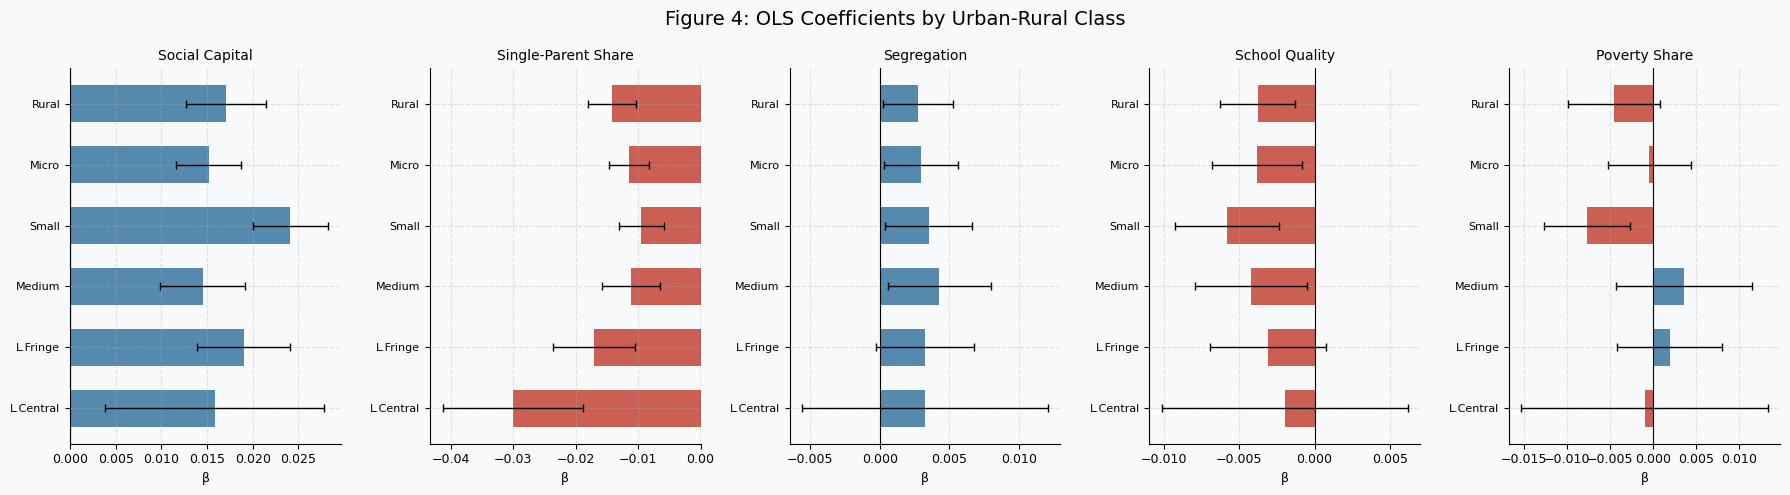

In [13]:
%matplotlib inline

ur_classes = ["Large Central Metro", "Large Fringe Metro", "Medium Metro",
              "Small Metro", "Micropolitan", "Noncore Rural"]
ur_short   = ["L.Central", "L.Fringe", "Medium", "Small", "Micro", "Rural"]

coef_records = []
for ur in ur_classes:
    sub = analytic_std[analytic_std["urban_rural_label"] == ur]
    if len(sub) < 30:
        continue
    X_sub = sm.add_constant(
        StandardScaler().fit_transform(sub[PREDICTORS])
    )
    X_sub = pd.DataFrame(X_sub, columns=["const"] + PREDICTORS)
    res   = sm.OLS(sub["mobility"].values, X_sub).fit(cov_type="HC3")
    for pred in PREDICTORS:
        coef_records.append({
            "ur":   ur,
            "pred": pred_labels.get(pred, pred),
            "coef": res.params[pred],
            "lo":   res.conf_int().loc[pred, 0],
            "hi":   res.conf_int().loc[pred, 1],
        })

coef_df = pd.DataFrame(coef_records)

top_preds = ["Social Capital", "Single-Parent Share", "Segregation",
             "School Quality", "Poverty Share"]
fig, axes = plt.subplots(1, len(top_preds), figsize=(18, 5), sharey=False)
fig.suptitle("Figure 4: OLS Coefficients by Urban-Rural Class", fontsize=14)

for ax, pred in zip(axes, top_preds):
    sub = coef_df[coef_df["pred"] == pred].copy()
    sub = sub[sub["ur"].isin(ur_classes)]
    sub["ur_short"] = sub["ur"].map(dict(zip(ur_classes, ur_short)))
    colors_ = [RED if v < 0 else BLUE for v in sub["coef"]]
    y_pos = np.arange(len(sub))
    ax.barh(y_pos, sub["coef"].values, color=colors_, alpha=0.8, height=0.6)
    ax.errorbar(sub["coef"].values, y_pos,
                xerr=[sub["coef"] - sub["lo"], sub["hi"] - sub["coef"]],
                fmt="none", color="black", lw=1.0, capsize=3)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["ur_short"].values, fontsize=8)
    ax.set_title(pred, fontsize=10)
    ax.set_xlabel("β", fontsize=9)

plt.tight_layout()

#### OLS Summary Table

Coefficient table for baseline OLS and interaction OLS side by side, with standard errors and significance stars.

In [14]:
summary_rows = []
for pred in PREDICTORS:
    b0 = ols_base.params[pred]
    se0 = ols_base.bse[pred]
    p0 = ols_base.pvalues[pred]
    b1 = ols_interact.params.get(pred, float("nan"))
    se1 = ols_interact.bse.get(pred, float("nan"))
    p1 = ols_interact.pvalues.get(pred, float("nan"))

    def stars(p):
        if p < 0.01: return "***"
        if p < 0.05: return "**"
        if p < 0.10: return "*"
        return ""

    summary_rows.append({
        "Predictor":          pred_labels.get(pred, pred),
        "β (Baseline)":       f"{b0:.4f}{stars(p0)}",
        "SE (Baseline)":      f"({se0:.4f})",
        "β (Interactions)":   f"{b1:.4f}{stars(p1)}",
        "SE (Interactions)":  f"({se1:.4f})",
    })

results_df = pd.DataFrame(summary_rows)
print(f"Baseline OLS has R²: {ols_base.rsquared:.3f} | Adj R²: {ols_base.rsquared_adj:.3f} | N: {int(ols_base.nobs)}")
print(f"Interaction OLS has R²: {ols_interact.rsquared:.3f} | Adj R²: {ols_interact.rsquared_adj:.3f} | N: {int(ols_interact.nobs)}")
results_df

Baseline OLS has R²: 0.627 | Adj R²: 0.625 | N: 1578
Interaction OLS has R²: 0.629 | Adj R²: 0.626 | N: 1578


,Predictor,β (Baseline),SE (Baseline),β (Interactions),SE (Interactions)
0,Segregation,0.0033***,(0.0008),0.0035***,(0.0008)
1,School Quality,-0.0057***,(0.0008),-0.0058***,(0.0009)
2,Single-Parent Share,-0.0167***,(0.0012),-0.0165***,(0.0012)
3,Gini Inequality,-0.0001,(0.0009),-0.0000,(0.0009)
4,Mean Commute Time,-0.0053***,(0.0008),-0.0051***,(0.0009)
5,Social Capital,0.0199***,(0.0012),0.0203***,(0.0012)
6,Poverty Share,-0.0008,(0.0014),-0.0014,(0.0016)
7,Median HH Income,0.0009,(0.0014),0.0001,(0.0016)
8,Population Density,0.0029,(0.0023),0.0031,(0.0025)


### Random Forest

Trains a Random Forest regressor on the same 9 standardized predictors and outcome. Hyperparameters tuned via 5-fold cross-validation. Reports OOB R², CV R², and compares to OLS baseline. Feature importance assessed via SHAP values. 

OLS R²: 0.627
RF OOB R²: 0.664
RF CV R²: 0.660


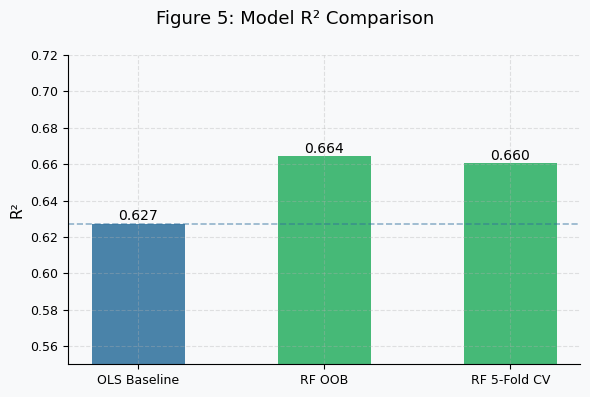

In [16]:
%matplotlib inline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import shap

X = X_std.values
y_vals = y.values

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=0.33,
    min_samples_leaf=5,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y_vals)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y_vals, cv=cv, scoring="r2").mean()
oob_r2 = rf.oob_score_
ols_r2 = ols_base.rsquared

print(f"OLS R²: {ols_r2:.3f}")
print(f"RF OOB R²: {oob_r2:.3f}")
print(f"RF CV R²: {cv_r2:.3f}")

# Figure 5: model comparison bar
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Figure 5: Model R² Comparison", fontsize=13)
labels = ["OLS Baseline", "RF OOB", "RF 5-Fold CV"]
vals = [ols_r2, oob_r2, cv_r2]
colors_ = [BLUE, GREEN, GREEN]
bars = ax.bar(labels, vals, color=colors_, alpha=0.85, width=0.5)
ax.set_ylim(0.55, 0.72)
ax.set_ylabel("R²")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(ols_r2, color=BLUE, lw=1.2, ls="--", alpha=0.5)
plt.tight_layout()

(1) SHAP Values: Feature Importance and Directions

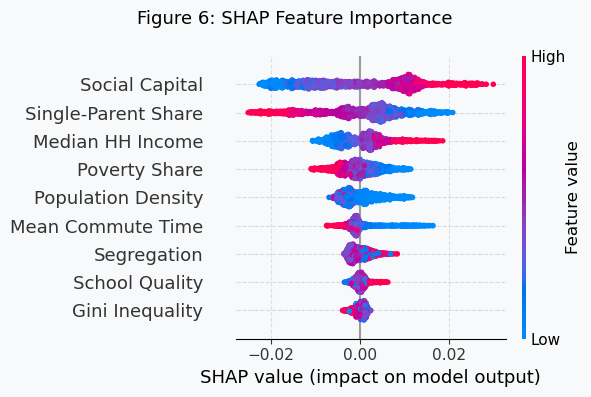

In [18]:
%matplotlib inline

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_df = pd.DataFrame(shap_values, columns=PREDICTORS)

fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Figure 6: SHAP Feature Importance", fontsize=13)
shap.summary_plot(shap_values, X, feature_names=[pred_labels[p] for p in PREDICTORS],
                  show=False, plot_size=None)
plt.tight_layout()

(2) SHAP Interaction Effects: Mean absolute SHAP interaction values between the top feature pairs. Captures how much each pair of features jointly shifts predictions beyond their individual contributions.

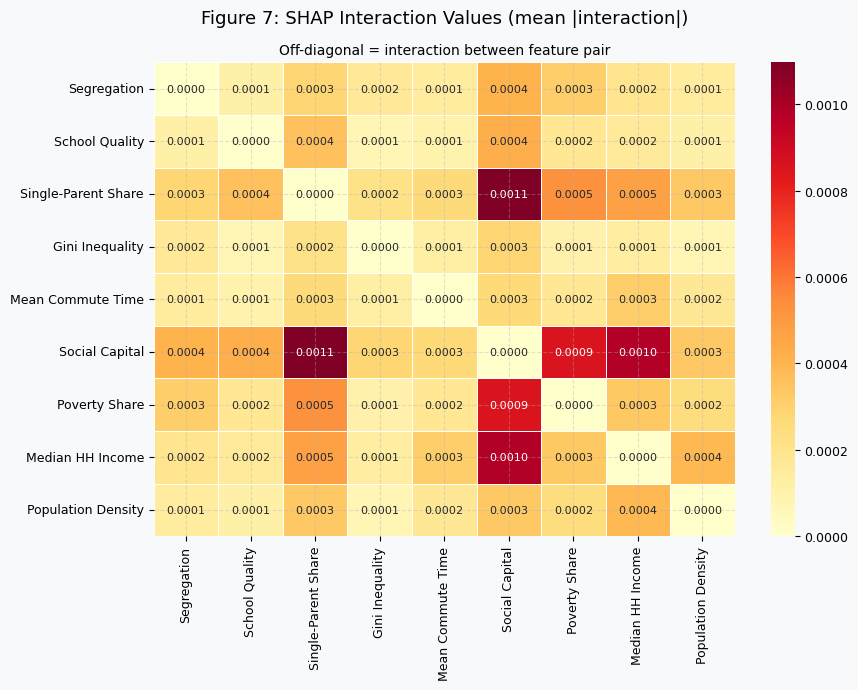

In [19]:
%matplotlib inline

shap_interact = explainer.shap_interaction_values(X)

# Mean absolute interaction matrix (off-diagonal = true interactions)
interact_mat = np.abs(shap_interact).mean(axis=0)
np.fill_diagonal(interact_mat, 0)

labels_short = [pred_labels[p] for p in PREDICTORS]
interact_df  = pd.DataFrame(interact_mat, index=labels_short, columns=labels_short)

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Figure 7: SHAP Interaction Values (mean |interaction|)", fontsize=13)
sns.heatmap(interact_df, ax=ax, cmap="YlOrRd", annot=True, fmt=".4f",
            annot_kws={"size": 8}, linewidths=0.4)
ax.set_title("Off-diagonal = interaction between feature pair", fontsize=10)
plt.tight_layout()

(3) Partial Dependence Plots - Top Features: Shows the marginal effect of each top predictor on mobility, averaging over all other features. Reveals non-linearities the linear model cannot capture.

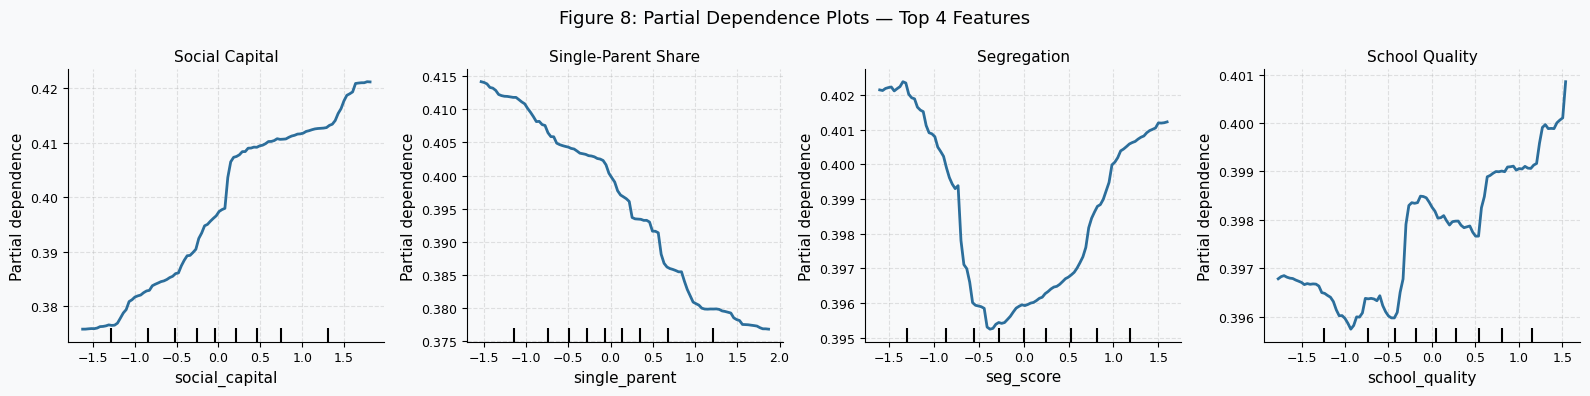

In [20]:
%matplotlib inline
from sklearn.inspection import PartialDependenceDisplay

top4_idx = [PREDICTORS.index(p) for p in
            ["social_capital", "single_parent", "seg_score", "school_quality"]]
top4_labels = ["Social Capital", "Single-Parent Share", "Segregation", "School Quality"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Figure 8: Partial Dependence Plots — Top 4 Features", fontsize=13)

for ax, idx, label in zip(axes, top4_idx, top4_labels):
    PartialDependenceDisplay.from_estimator(
        rf, X, [idx], ax=ax,
        feature_names=PREDICTORS,
        line_kw={"color": BLUE, "lw": 2}
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()

### Final Results Table:

In [21]:
import pandas as pd
import numpy as np

# SHAP mean absolute values (overall importance)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=PREDICTORS
)

# SHAP mean absolute interaction (row sum, excluding diagonal)
interact_importance = pd.Series(
    interact_mat.sum(axis=1),
    index=labels_short
).rename(index={v: k for k, v in pred_labels.items()})

# OLS significance stars
def stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

rows = []
for pred in PREDICTORS:
    b   = ols_base.params[pred]
    p   = ols_base.pvalues[pred]
    rows.append({
        "Predictor":            pred_labels[pred],
        "OLS β":                f"{b:.4f}",
        "Sig.":                 stars(p),
        "OLS p-value":          f"{p:.3f}",
        "SHAP Importance":      f"{shap_importance[pred]:.4f}",
        "SHAP Interaction Sum": f"{interact_importance.get(pred, 0):.4f}",
    })

final_df = pd.DataFrame(rows).sort_values(
    "SHAP Importance", ascending=False
).reset_index(drop=True)

print(f"OLS R²: {ols_base.rsquared:.3f} | RF CV R²: {cv_r2:.3f} | "
      f"RF OOB R²: {oob_r2:.3f} | N = {len(analytic)}")
final_df

OLS R²: 0.627 | RF CV R²: 0.660 | RF OOB R²: 0.664 | N = 1578


,Predictor,OLS β,Sig.,OLS p-value,SHAP Importance,SHAP Interaction Sum
0,Social Capital,0.0199,***,0.000,0.0112,0.0047
1,Single-Parent Share,-0.0167,***,0.000,0.0078,0.0035
2,Median HH Income,0.0009,,0.537,0.0042,0.0030
3,Poverty Share,-0.0008,,0.578,0.0032,0.0027
4,Population Density,0.0029,,0.210,0.0030,0.0018
5,Mean Commute Time,-0.0053,***,0.000,0.0023,0.0016
6,Segregation,0.0033,***,0.000,0.0018,0.0018
7,School Quality,-0.0057,***,0.000,0.0009,0.0015
8,Gini Inequality,-0.0001,,0.872,0.0009,0.0012
